<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
# **Ejercicio, Traductor**

Importamos las librerias necesarias

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.models import Model
import pickle
import os

Descargamos el dataset de traducción de Español-Inglés

In [ ]:
if not os.path.exists('spa-eng'):
    os.system("curl -L -o spa-eng.zip http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip")
    os.system("unzip -q spa-eng.zip")

with open("./spa-eng/spa.txt") as f:
    lines = f.read().split("\n")[:-1]

Definimos el número máximo de oraciones y la semilla

In [ ]:
MAX_NUM_SENTENCES = 10000

np.random.seed(40)
np.random.shuffle(lines)

Cargamos los datos

In [ ]:
input_sentences, output_sentences, output_sentences_inputs = [], [], []

for i, line in enumerate(lines):
    if i >= MAX_NUM_SENTENCES:
        break
    if '\t' not in line:
        continue
    input_sentence, output = line.rstrip().split('\t')[:2]
    output_sentences.append(output + ' <eos>')
    output_sentences_inputs.append('<sos> ' + output)
    input_sentences.append(input_sentence)

print(f"Oraciones cargadas: {len(input_sentences)}")

Oraciones cargadas: 10000


In [ ]:
print(input_sentences[0])
print(output_sentences[0])
print(output_sentences_inputs[0])

Somebody stole my car.
Alguien robó mi auto. <eos>
<sos> Alguien robó mi auto.


Aplicamos tokenización

In [ ]:
MAX_VOCAB_SIZE = 8000

input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)
word2idx_inputs = input_tokenizer.word_index

#Solo se tomarán en cuenta las 8000 palabras más frecuentes y se eliminan signos de puntuación
output_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n'
)

output_tokenizer.fit_on_texts(["<sos>", "<eos>"] + output_sentences)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)
word2idx_outputs = output_tokenizer.word_index

num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE)

max_input_len = 20
max_out_len   = 22

print(f"Vocabulario EN: {len(word2idx_inputs)} | ES: {len(word2idx_outputs)}")
print(f"max_input_len={max_input_len}  max_out_len={max_out_len}")

Vocabulario EN: 4977 | ES: 7803
max_input_len=20  max_out_len=22


Aplicamos padding a las secuencias

In [ ]:
encoder_input_sequences  = pad_sequences(input_integer_seq,        maxlen=max_input_len)
decoder_input_sequences  = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding='post')
decoder_output_sequences = pad_sequences(output_integer_seq,       maxlen=max_out_len, padding='post')

In [ ]:
print(encoder_input_sequences[0])
print(decoder_input_sequences[0])
print(decoder_output_sequences[0])

[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 702 752
  16 104]
[3434  157  613   21  246    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]
[157 613  21 246   1   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0]


Definimos función para obtener un tf.data.Dataset.

Esta función construye un tf.data.Dataset que genera batches de (encoder_in, decoder_in) a one-hot targets.

In [ ]:
def make_dataset(enc_seqs, dec_in_seqs, dec_out_seqs, batch_size, num_classes):

    n = len(enc_seqs)

    def generator():
        for i in range(n):
            yield (
                enc_seqs[i].astype(np.int32),
                dec_in_seqs[i].astype(np.int32),
                dec_out_seqs[i].astype(np.int32),
            )

    def encode_one_hot(enc, dec_in, dec_out):
        y = tf.one_hot(dec_out, depth=num_classes)          # shape (max_out_len, num_classes)
        return (enc, dec_in), y

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(max_input_len,), dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
        )
    )
    ds = ds.map(encode_one_hot, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

Aplicamos la función en el dataset para obtener el train y validation set

In [ ]:
BATCH_SIZE = 64
val_split  = 0.15
split_idx  = int(len(encoder_input_sequences) * (1 - val_split))

train_ds = make_dataset(
    encoder_input_sequences[:split_idx],
    decoder_input_sequences[:split_idx],
    decoder_output_sequences[:split_idx],
    BATCH_SIZE, num_words_output
)
val_ds = make_dataset(
    encoder_input_sequences[split_idx:],
    decoder_input_sequences[split_idx:],
    decoder_output_sequences[split_idx:],
    BATCH_SIZE, num_words_output
)

Definimos función para descargar los embeddings de GloVe

In [ ]:
def _is_valid_pickle(path):
    try:
        with open(path, 'rb') as f:
            head = f.read(20)
        return b'<html' not in head.lower() and b'<!doctype' not in head.lower()
    except Exception:
        return False

_PKL_PATH = 'gloveembedding.pkl'
_FILE_ID  = '1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94'

if not os.path.exists(_PKL_PATH) or not _is_valid_pickle(_PKL_PATH):
    print("Descargando gloveembedding.pkl desde Google Drive...")
    if os.path.exists(_PKL_PATH):
        os.remove(_PKL_PATH)
    try:
        import gdown
        gdown.download(id=_FILE_ID, output=_PKL_PATH, quiet=False)
    except Exception:
        os.system(f"curl -L -o {_PKL_PATH} "
                  f"'https://drive.google.com/u/0/uc?id={_FILE_ID}&export=download&confirm=t'")
    if not _is_valid_pickle(_PKL_PATH):
        raise ValueError("El archivo descargado no es un pickle válido.")
    print("Descarga completada.")
else:
    print("gloveembedding.pkl ya disponible.")

gloveembedding.pkl ya disponible.


Definimos función para cargar los embeddings de GloVe

In [ ]:
def load_glove_embeddings(pkl_path):
    """Carga el pickle de GloVe y devuelve (word2idx, matrix_fn)."""
    max_bytes = 2**28 - 1
    raw = bytearray()
    sz  = os.path.getsize(pkl_path)
    with open(pkl_path, 'rb') as f:
        for _ in range(0, sz, max_bytes):
            raw += f.read(max_bytes)
    embeddings = pickle.loads(raw)
    idx_array  = np.arange(embeddings.shape[0])
    word2idx   = dict(zip(embeddings['word'], idx_array))
    return embeddings, word2idx

Definimos función para obtener el embedding por palabra

In [ ]:
def get_word_embedding(word, embeddings, word2idx, n_features=50):
    i = word2idx.get(word, -1)
    return embeddings[i]['embedding'] if i != -1 else np.zeros(n_features)

Definimos función para armar la matriz de embeddings

In [ ]:
def build_embedding_matrix(word2idx_inputs, embeddings, word2idx_glove,
                            nb_words, embed_dim=50):
    matrix = np.zeros((nb_words, embed_dim))
    for word, i in word2idx_inputs.items():
        if i < nb_words:
            vec = get_word_embedding(word, embeddings, word2idx_glove, embed_dim)
            if vec is not None and len(vec) > 0:
                matrix[i] = vec
    return matrix

In [ ]:
EMBED_DIM = 50
nb_words  = min(MAX_VOCAB_SIZE, len(word2idx_inputs))

glove_embeddings, glove_word2idx = load_glove_embeddings(_PKL_PATH)
embedding_matrix = build_embedding_matrix(
    word2idx_inputs, glove_embeddings, glove_word2idx, nb_words, EMBED_DIM
)
print(f"Embeddings nulos: {np.sum(np.sum(embedding_matrix**2, axis=1) == 0)}")

Embeddings nulos: 212


### **Modelo Seq2Seq**

In [ ]:
n_units = 256

Definimos función para armar el encoder. Esta función devuelve (encoder_inputs, encoder_states, encoder_emb_layer, encoder_lstm_layer) para poder reusar las capas en el modelo de inferencia.

In [ ]:
def build_encoder(nb_words, embed_dim, embedding_matrix, max_input_len, n_units):

    enc_inputs   = Input(shape=(max_input_len,), name='encoder_inputs')

    enc_emb_layer = Embedding(
        input_dim=nb_words,
        output_dim=embed_dim,
        input_length=max_input_len,
        weights=[embedding_matrix],
        trainable=False,
        name='encoder_embedding'
    )
    enc_emb = Dropout(0.3, name='encoder_dropout')(enc_emb_layer(enc_inputs))

    enc_lstm_layer = LSTM(n_units, return_state=True, name='encoder_lstm')
    _, state_h, state_c = enc_lstm_layer(enc_emb)

    return enc_inputs, [state_h, state_c], enc_emb_layer, enc_lstm_layer

Definimos función para armar el decoder. Esta función devuelve (decoder_inputs, decoder_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer)
    para reusar las capas en inferencia.

In [ ]:
def build_decoder(num_words_output, max_out_len, n_units, encoder_states):

    dec_inputs = Input(shape=(max_out_len,), name='decoder_inputs')

    dec_emb_layer = Embedding(
        input_dim=num_words_output,
        output_dim=n_units,
        input_length=max_out_len,
        name='decoder_embedding'
    )
    dec_emb = Dropout(0.3, name='decoder_dropout')(dec_emb_layer(dec_inputs))

    dec_lstm_layer = LSTM(n_units, return_sequences=True, return_state=True,
                          name='decoder_lstm')
    dec_out, _, _  = dec_lstm_layer(dec_emb, initial_state=encoder_states)

    dec_dense_layer = Dense(num_words_output, activation='softmax', name='decoder_dense')
    dec_out         = dec_dense_layer(dec_out)

    return dec_inputs, dec_out, dec_emb_layer, dec_lstm_layer, dec_dense_layer

Construimos encoder y decoder

In [ ]:
enc_inputs, enc_states, enc_emb_layer, enc_lstm_layer = build_encoder(
    nb_words, EMBED_DIM, embedding_matrix, max_input_len, n_units
)
dec_inputs, dec_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer = build_decoder(
    num_words_output, max_out_len, n_units, enc_states
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model = Model([enc_inputs, dec_inputs], dec_outputs)

Definimos callbacks

In [ ]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1
)
early_stop = EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True, verbose=1
)

Compilamos el modelo

In [ ]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    metrics=['accuracy']
)

Entrenamos el modelo

In [ ]:
hist = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[lr_scheduler, early_stop]
)

Epoch 1/30
    132/Unknown 10s 54ms/step - accuracy: 0.6504 - loss: 4.7246

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


133/133 ━━━━━━━━━━━━━━━━━━━━ 12s 65ms/step - accuracy: 0.6795 - loss: 3.0156 - val_accuracy: 0.7190 - val_loss: 2.0189 - learning_rate: 5.0000e-04
Epoch 2/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.7279 - loss: 1.9411 - val_accuracy: 0.7306 - val_loss: 1.9449 - learning_rate: 5.0000e-04
Epoch 3/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.7333 - loss: 1.8773 - val_accuracy: 0.7332 - val_loss: 1.9102 - learning_rate: 5.0000e-04
Epoch 4/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - accuracy: 0.7366 - loss: 1.8287 - val_accuracy: 0.7365 - val_loss: 1.8692 - learning_rate: 5.0000e-04
Epoch 5/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - accuracy: 0.7409 - loss: 1.7727 - val_accuracy: 0.7410 - val_loss: 1.8278 - learning_rate: 5.0000e-04
Epoch 6/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 20s 148ms/step - accuracy: 0.7449 - loss: 1.7180 - val_accuracy: 0.7443 - val_loss: 1.7922 - learning_rate: 5.0000e-04
Epoch 7/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy

Visualizamos el accuracy durante el entrenamiento

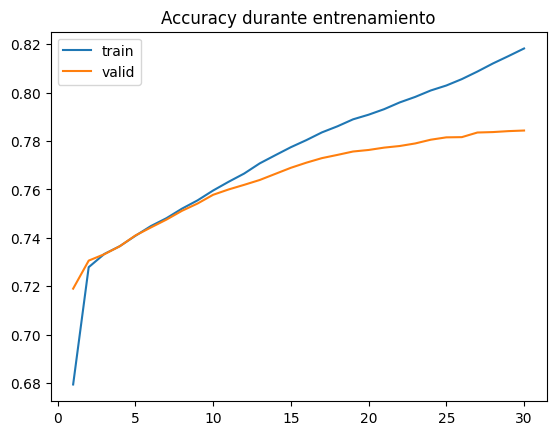

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

epoch_count = range(1, len(hist.history['accuracy']) + 1)
sns.lineplot(x=epoch_count, y=hist.history['accuracy'],     label='train')
sns.lineplot(x=epoch_count, y=hist.history['val_accuracy'], label='valid')
plt.title("Accuracy durante entrenamiento")
plt.show()

### **Inferencia Modelo Seq2Seq**

Definimos el modelo Seq2Seq para realizar inferencia

In [ ]:
def build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer, n_units):
    """Modelo de encoder que solo devuelve los estados."""
    enc_emb = enc_emb_layer(enc_inputs)                    # reutiliza pesos entrenados
    _, state_h, state_c = enc_lstm_layer(enc_emb)
    return Model(enc_inputs, [state_h, state_c])


def build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units):
    """Modelo de decoder paso a paso (un token por vez)."""
    dec_input_single = Input(shape=(1,), name='dec_input_single')
    dec_state_h_in   = Input(shape=(n_units,), name='dec_state_h')
    dec_state_c_in   = Input(shape=(n_units,), name='dec_state_c')

    dec_emb_single = dec_emb_layer(dec_input_single)      # reutiliza pesos entrenados
    dec_out, h_out, c_out = dec_lstm_layer(
        dec_emb_single,
        initial_state=[dec_state_h_in, dec_state_c_in]
    )
    dec_out = dec_dense_layer(dec_out)

    return Model(
        [dec_input_single, dec_state_h_in, dec_state_c_in],
        [dec_out, h_out, c_out]
    )

In [ ]:
encoder_model = build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer, n_units)
decoder_model = build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units)

Aplicamos inferencia greedy

In [ ]:
idx2word_input  = {v: k for k, v in word2idx_inputs.items()}
idx2word_target = {v: k for k, v in word2idx_outputs.items()}

Definimos funciones para realizar traducciones

In [ ]:
def translate_sentence(input_seq):
    h, c = encoder_model.predict(input_seq, verbose=0)    # desempaqueta directo
    target_seq      = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs['<sos>']
    eos = word2idx_outputs['<eos>']

    output_sentence = []
    for _ in range(max_out_len):
        output_tokens, h, c = decoder_model.predict(
            [target_seq, h, c], verbose=0                 # estados como args separados
        )
        idx = np.argmax(output_tokens[0, 0, :])
        if idx == eos:
            break
        if idx > 0:
            output_sentence.append(idx2word_target[idx])
        target_seq[0, 0] = idx

    return ' '.join(output_sentence)


def translate(text):
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_input_len)
    return translate_sentence(seq)

Realizamos pruebas

In [ ]:
print("\n--- Ejemplos del dataset ---")
for _ in range(5):
    i    = np.random.randint(len(input_sentences))
    seq  = encoder_input_sequences[i:i+1]
    pred = translate_sentence(seq)
    print(f"EN: {input_sentences[i]}")
    print(f"ES (real): {output_sentences[i].replace(' <eos>', '')}")
    print(f"ES (pred): {pred}\n")

print("--- Frases nuevas ---")
for s in ["My mother says hi.", "Where is the train station?",
          "I love learning languages.", "Can you help me?"]:
    print(f"EN: {s}")
    print(f"ES: {translate(s)}\n")


--- Ejemplos del dataset ---
EN: Would you prefer to do that today?
ES (real): ¿Preferirías hacerlo hoy?
ES (pred): tienes que hacer hacer algo

EN: He is terrible at math.
ES (real): Él es pésimo en matemáticas.
ES (pred): él es muy viejo

EN: Tom has left, but Mary is still here.
ES (real): Tom se ha ido, pero Mary está todavía aquí.
ES (pred): tom se ha estado en la última vez de la escuela

EN: Tom listens to jazz.
ES (real): Tomás escucha jazz.
ES (pred): tom quiere hablar

EN: I haven't ever seen one of these before.
ES (real): Nunca he visto uno de éstos hasta ahora.
ES (pred): no he visto nada de las dos

--- Frases nuevas ---
EN: My mother says hi.
ES: mi hermano es mi nombre

EN: Where is the train station?
ES: dónde está en el río

EN: I love learning languages.
ES: yo puedo tus libros

EN: Can you help me?
ES: puedes ir

